Length of dnaA: 48
Length of dnaB: 48
CGC count in dnaA: 0
CGC count in dnaB: 1


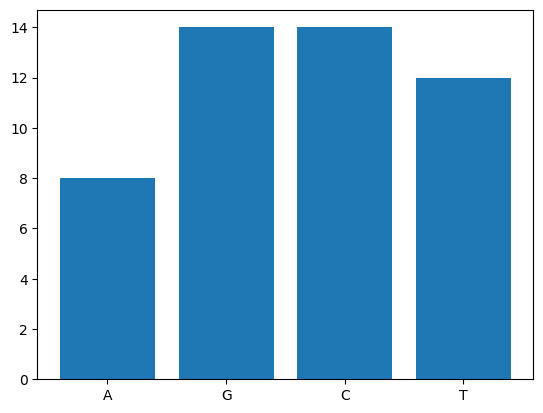

In [5]:
from Bio.Seq import Seq 

# Define DNA sequences
dnaA = Seq("AGCTTGCAGCGTCCGTTAGCTCGAGTCCAGGACGTTAGTCCTGCAGTC")
dnaB = Seq("CAGTAAGTTGCCGTTAGCGCGTAGTGCCAGTAAGCGGCTCGTTAGTGG")

# Length of the sequences
len(dnaA)
len(dnaB)

# Count codons
cgc_count_dnaA = dnaA.count("CGC")
cgc_count_dnaB = dnaB.count("CGC")

# First occurrence of "CAGTC"
first_cgc_dnaA = dnaA.find("CAGTC")
first_cgc_dnaB = dnaB.find("CAGTC")

## Slice sequences
# [Start : End : Step]
# [ : : -1] to reverse the sequence
# [ -10 : ] to get the last 10 bases
# [ : -10] to get all but the last 10 bases

# Create new DNA sequence dnaC by combining parts of dnaA and dnaB
dnaC = dnaA[:15] + dnaB[-10:] 

# Reverse sequences
rev_dnaC = dnaC[::-1]

# Plot sequences
from collections import Counter
from matplotlib import pyplot as plt

counter_A = Counter(dnaA)

plt.bar(counter_A.keys(), counter_A.values())

# Print station
print("Length of dnaA:", len(dnaA))
print("Length of dnaB:", len(dnaB))
print("CGC count in dnaA:", cgc_count_dnaA)
print("CGC count in dnaB:", cgc_count_dnaB)


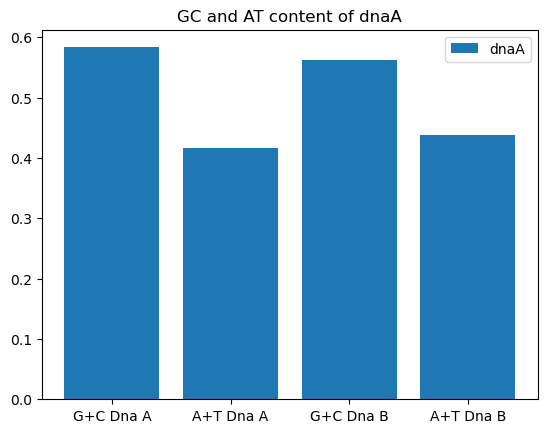

<Figure size 640x480 with 0 Axes>

Molecular weight of dnaA: 14831.413499999997
Molecular weight of dnaB: 14975.510499999997
Melting temperature of dnaA: 152.0
Melting temperature of dnaB: 150.0
GC content of dnaA: 0.5833333333333334
GC content of dnaB: 0.5625
AT content of dnaA: 0.41666666666666663
AT content of dnaB: 0.4375


In [6]:
from Bio.SeqUtils import molecular_weight as mw, MeltingTemp as mt, gc_fraction
from matplotlib import pyplot as plt

dnaA = Seq("AGCTTGCAGCGTCCGTTAGCTCGAGTCCAGGACGTTAGTCCTGCAGTC")
dnaB = Seq("CAGTAAGTTGCCGTTAGCGCGTAGTGCCAGTAAGCGGCTCGTTAGTGG")

# Molecular weight
molecular_weightB = mw(dnaB)
molecular_weightA = mw(dnaA)

# Melting temperature
melting_tempB = mt.Tm_Wallace(dnaB)
melting_tempA = mt.Tm_Wallace(dnaA)

# GC content
gc_contentB = gc_fraction(dnaB)
gc_contentA = gc_fraction(dnaA)

# AT content
at_contentB = 1 - gc_contentB 
at_contentA = 1 - gc_contentA

# GCAT content
plt.bar(['G+C Dna A', 'A+T Dna A', 'G+C Dna B', 'A+T Dna B'], [gc_contentA, at_contentA, gc_contentB, at_contentB])
plt.legend(['dnaA' , 'dnaB'])
plt.title('GC and AT content of dnaA')
plt.figure()
plt.show()

# Print Station
print("Molecular weight of dnaA:", molecular_weightA)
print("Molecular weight of dnaB:", molecular_weightB)
print("Melting temperature of dnaA:", melting_tempA)
print("Melting temperature of dnaB:", melting_tempB)
print("GC content of dnaA:", gc_contentA)
print("GC content of dnaB:", gc_contentB)
print("AT content of dnaA:", at_contentA)
print("AT content of dnaB:", at_contentB)





In [7]:
# transcribe DNA to mRNA
mrnaA = dnaA.transcribe()
mrnaB = dnaB.transcribe()

# combine mRNA sequences 24 
mrnaC = mrnaA[:24] + mrnaB[-21:]

# translate mRNA to protein
proteinA = mrnaA.translate()
proteinB = mrnaB.translate()
proteinC = mrnaC.translate()

# transcribe mRNA back to DNA
dnaC = mrnaC.back_transcribe()

# Complemary sequence
comp_dnaA = dnaA.complement()
comp_dnaB = dnaB.complement()

print("mRNA A:", mrnaA)
print("mRNA B:", mrnaB)
print("mRNA C:", mrnaC)
print("Protein A:", proteinA)
print("Protein B:", proteinB)
print("Protein C:", proteinC)
print("DNA C from mRNA C:", dnaC)
print("Complementary DNA A:", comp_dnaA)
print("Complementary DNA B:", comp_dnaB)

mRNA A: AGCUUGCAGCGUCCGUUAGCUCGAGUCCAGGACGUUAGUCCUGCAGUC
mRNA B: CAGUAAGUUGCCGUUAGCGCGUAGUGCCAGUAAGCGGCUCGUUAGUGG
mRNA C: AGCUUGCAGCGUCCGUUAGCUCGACAGUAAGCGGCUCGUUAGUGG
Protein A: SLQRPLARVQDVSPAV
Protein B: Q*VAVSA*CQ*AAR*W
Protein C: SLQRPLARQ*AAR*W
DNA C from mRNA C: AGCTTGCAGCGTCCGTTAGCTCGACAGTAAGCGGCTCGTTAGTGG
Complementary DNA A: TCGAACGTCGCAGGCAATCGAGCTCAGGTCCTGCAATCAGGACGTCAG
Complementary DNA B: GTCATTCAACGGCAATCGCGCATCACGGTCATTCGCCGAGCAATCACC


In [8]:
from Bio import pairwise2

pairwise2.align.localxx(dnaA, dnaB)
pairwise2.align.globalxx(dnaA, dnaB)

# Hemming distance
hemming_distance = 0
for x,y in zip(dnaA, dnaB):
    if x != y:
        hemming_distance += 1
print(hemming_distance)

# Levenshtein distance
from Levenshtein import distance as ld
print(ld (str(dnaA), str(dnaB)))

36
22
